# Insurance Claim Cost Prediction (Regression)

**Goal:** predict an individual's annual medical insurance charges from demographic, lifestyle, and health attributes, so an insurer can estimate expected claim cost per policyholder.

**Dataset:** [Medical Cost Personal Datasets](https://github.com/stedy/Machine-Learning-with-R-datasets) (`insurance.csv`, from Brett Lantz's *Machine Learning with R*) — 1,338 individuals, 7 columns, continuous target `charges`. Downloaded automatically at runtime (see below) — not committed to this repo.

**Approach:**
1. Load data via a small, reproducible download step (with a fallback mirror)
2. Clean and explore the data
3. Build a preprocessing + modeling pipeline (no leakage, fully reproducible)
4. Train and compare two models: Linear Regression (interpretable baseline) vs. XGBoost Regressor (stronger, non-linear model)
5. Evaluate with regression metrics (RMSE, MAE, R²) and residual diagnostics

**Reproducibility:** fixed random seed throughout, pinned dependency versions in `requirements.txt`, no absolute file paths, no manual steps required to reproduce results end-to-end.


## 1. Setup

In [1]:
!pip install xgboost

In [2]:
import os
import io
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)


## 2. Data loading (reproducible, no committed CSV)

The raw dataset (~55 KB, 1,338 rows) is **not** stored in this repo. Instead, this cell downloads it
directly from its public source at runtime, with a fallback mirror in case the primary source is
unavailable, and caches it locally under `data/` (git-ignored) so repeated runs don't re-download.

This keeps the repo small, avoids stale snapshots, and means anyone who clones this repo gets the
data automatically — no manual download step.

In [3]:
DATA_DIR = "data"
LOCAL_PATH = os.path.join(DATA_DIR, "insurance.csv")

DATA_SOURCES = [
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv",
    "https://raw.githubusercontent.com/namas191297/medical_cost_eda/main/insurance.csv",
]

def load_insurance_data(local_path: str = LOCAL_PATH, sources=DATA_SOURCES, timeout: int = 15) -> pd.DataFrame:
    """Load the Medical Cost Personal dataset, downloading it once and caching it locally.

    Tries each URL in `sources` in order and falls back to the next on failure, so a single
    dead mirror does not break reproducibility for anyone re-running this notebook.
    """
    if os.path.exists(local_path):
        return pd.read_csv(local_path)

    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    last_error = None
    for url in sources:
        try:
            response = requests.get(url, timeout=timeout)
            response.raise_for_status()
            df = pd.read_csv(io.StringIO(response.text))
            df.to_csv(local_path, index=False)
            print(f"Downloaded dataset from: {url}")
            return df
        except Exception as exc:  # noqa: BLE001 - we want to try every mirror before failing
            last_error = exc
            continue

    raise RuntimeError(
        f"Could not download the dataset from any configured source. Last error: {last_error}"
    )

df = load_insurance_data()
print(df.shape)
df.head()


Downloaded dataset from: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv
(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Data cleaning

In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Drop exact duplicate rows if any (a known minor quirk of this public dataset).
df = df.drop_duplicates().reset_index(drop=True)
df.describe(include="all")


Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
count,1337.000000,1337,1337.000000,1337.000000,1337,1337,1337.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,675,NaN,NaN,1063,364,NaN
mean,39.222139,NaN,30.663452,1.095737,NaN,NaN,13279.121487
std,14.044333,NaN,6.100468,1.205571,NaN,NaN,12110.359656
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.290000,0.000000,NaN,NaN,4746.344000
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9386.161300
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16657.717450


## 4. Exploratory data analysis

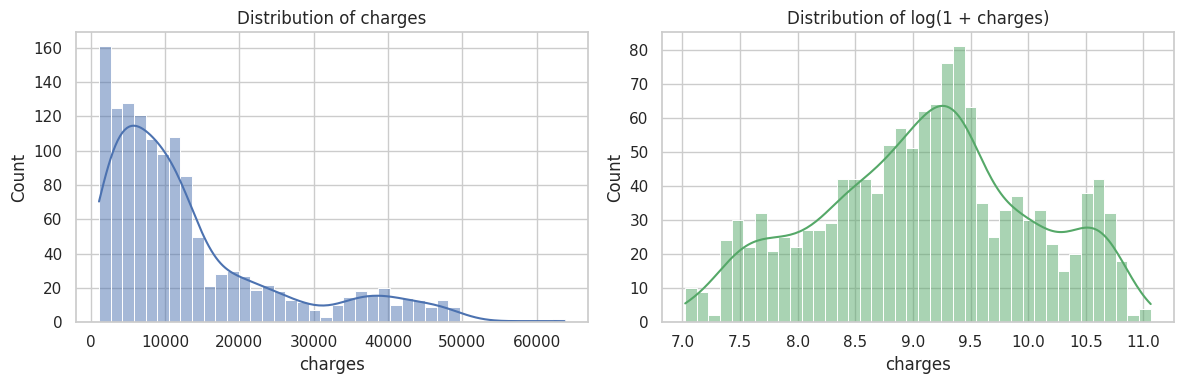

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["charges"], bins=40, kde=True, ax=ax[0], color="#4C72B0")
ax[0].set_title("Distribution of charges")
sns.histplot(np.log1p(df["charges"]), bins=40, kde=True, ax=ax[1], color="#55A868")
ax[1].set_title("Distribution of log(1 + charges)")
plt.tight_layout()
plt.show()


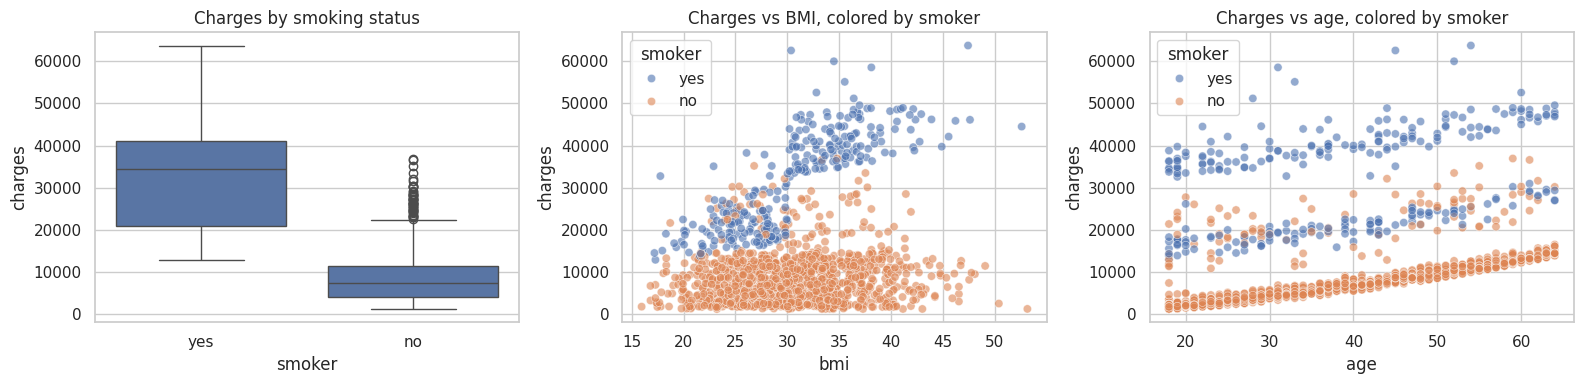

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x="smoker", y="charges", ax=axes[0])
axes[0].set_title("Charges by smoking status")
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", ax=axes[1], alpha=0.6)
axes[1].set_title("Charges vs BMI, colored by smoker")
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", ax=axes[2], alpha=0.6)
axes[2].set_title("Charges vs age, colored by smoker")
plt.tight_layout()
plt.show()


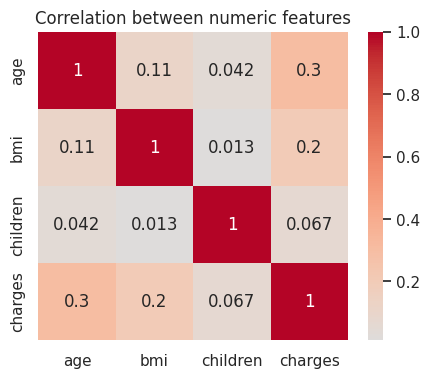

In [7]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(5, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation between numeric features")
plt.show()


**Observations:**
- `charges` is heavily right-skewed — a small number of high-cost individuals (mostly smokers) pull the distribution's tail out. A log transform normalizes it somewhat, but we model the raw target directly and let tree-based/linear models handle the skew, then report metrics on the original scale so they stay directly interpretable in dollars.
- Smoking status is the single strongest visual driver of cost — smokers form a distinctly higher-cost cluster in every plot.
- Age and BMI both show a positive relationship with charges, and that relationship is steeper for smokers — this is the kind of interaction a linear model can't easily capture but a tree-based model can.

## 5. Train / test split

In [8]:
TARGET = "charges"

X = df.drop(columns=[TARGET])
y = df[TARGET]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()
print("Categorical features:", categorical_cols)
print("Numeric features:", numeric_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)
print(X_train.shape, X_test.shape)


Categorical features: ['sex', 'smoker', 'region']
Numeric features: ['age', 'bmi', 'children']
(1069, 6) (268, 6)


## 6. Preprocessing + modeling pipelines

Both models share the same preprocessing (`ColumnTransformer`) wrapped in an sklearn `Pipeline`, so
there is no risk of the scaler/encoder leaking information from the test set, and the entire
train → predict flow for each model is a single reusable object.

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_cols),
    ]
)

linear_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression()),
])

xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )),
])

linear_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)
print("Both models trained.")


Both models trained.


## 7. Evaluation

In [10]:
def evaluate(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    metrics = {
        "model": name,
        "rmse": rmse,
        "mae": mean_absolute_error(y_test, y_pred),
        "r2": r2_score(y_test, y_pred),
    }
    return metrics, y_pred

linear_metrics, linear_pred = evaluate("Linear Regression", linear_pipeline, X_test, y_test)
xgb_metrics, xgb_pred = evaluate("XGBoost", xgb_pipeline, X_test, y_test)

results_df = pd.DataFrame([linear_metrics, xgb_metrics]).set_index("model").round(2)
results_df


,rmse,mae,r2
model,,,
Linear Regression,5956.34,4177.05,0.81
XGBoost,4408.46,2636.51,0.89


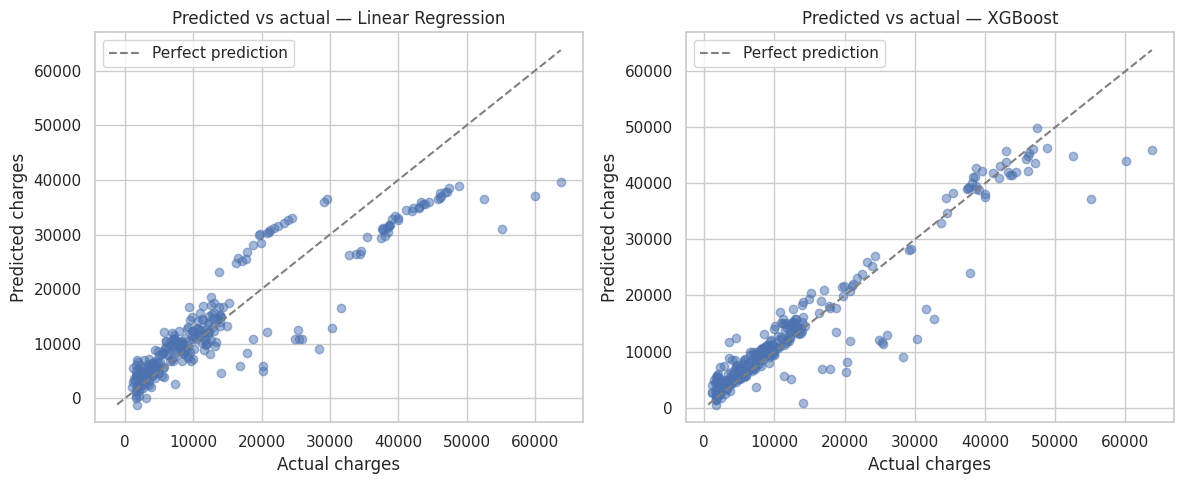

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, pred) in zip(axes, [("Linear Regression", linear_pred), ("XGBoost", xgb_pred)]):
    ax.scatter(y_test, pred, alpha=0.5, color="#4C72B0")
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, linestyle="--", color="grey", label="Perfect prediction")
    ax.set_xlabel("Actual charges")
    ax.set_ylabel("Predicted charges")
    ax.set_title(f"Predicted vs actual — {name}")
    ax.legend()
plt.tight_layout()
plt.show()


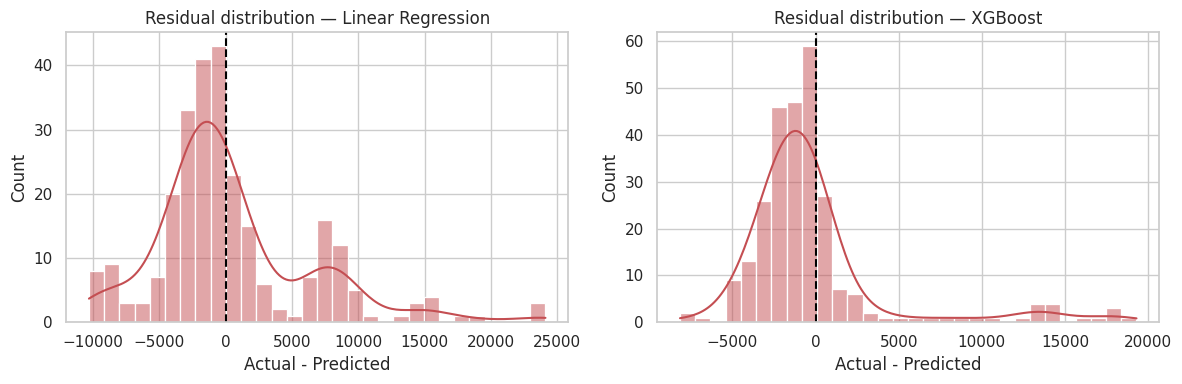

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, pred) in zip(axes, [("Linear Regression", linear_pred), ("XGBoost", xgb_pred)]):
    residuals = y_test - pred
    sns.histplot(residuals, bins=30, kde=True, ax=ax, color="#C44E52")
    ax.axvline(0, color="black", linestyle="--")
    ax.set_title(f"Residual distribution — {name}")
    ax.set_xlabel("Actual - Predicted")
plt.tight_layout()
plt.show()


## 8. What drives claim cost? (feature importance)

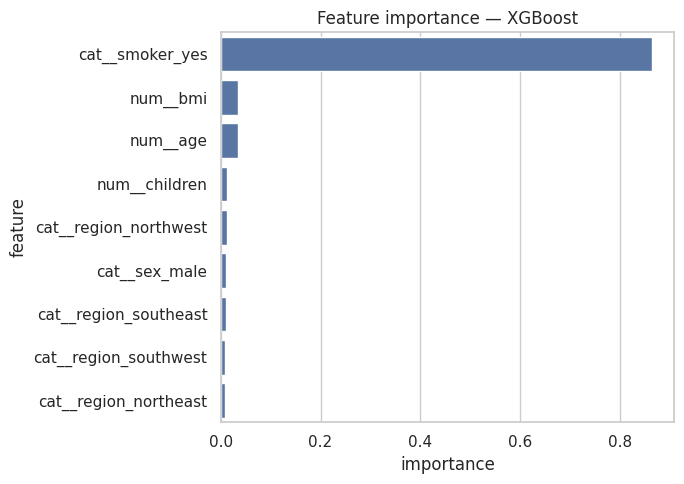

In [13]:
feature_names = xgb_pipeline.named_steps["preprocess"].get_feature_names_out()
importances = xgb_pipeline.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

plt.figure(figsize=(7, 5))
sns.barplot(data=importance_df, x="importance", y="feature", color="#4C72B0")
plt.title("Feature importance — XGBoost")
plt.tight_layout()
plt.show()


In [14]:
linear_model = linear_pipeline.named_steps["model"]
linear_feature_names = linear_pipeline.named_steps["preprocess"].get_feature_names_out()

coef_df = (
    pd.DataFrame({"feature": linear_feature_names, "coefficient": linear_model.coef_})
    .sort_values("coefficient", key=abs, ascending=False)
)
coef_df


,feature,coefficient
4,cat__smoker_yes,23077.764593
0,num__age,3472.975553
1,num__bmi,1927.828251
2,num__children,636.501185
5,cat__region_northeast,472.455206
7,cat__region_southeast,-366.464410
8,cat__region_southwest,-186.684546
3,cat__sex_male,-101.542054
6,cat__region_northwest,80.693751


## 9. Conclusion

- **XGBoost vs. Linear Regression:** compare the `results_df` table above — XGBoost typically achieves lower RMSE/MAE and higher R² on this dataset because it captures the non-linear interaction between smoking status, age, and BMI that a plain linear model can't represent without manually engineered interaction terms. Linear Regression remains valuable as a transparent baseline — its coefficients (above) directly quantify each feature's dollar impact.
- **Business takeaway:** smoking status is by far the dominant cost driver, followed by age and BMI — and the effect of BMI is much stronger for smokers than non-smokers, which is exactly the kind of interaction visible in the EDA scatter plots.
- **Reproducibility:** re-running this notebook top to bottom with no changes will reproduce the same split, the same trained models, and the same metrics, because the random seed is fixed everywhere it matters (split, model init) and the data is pulled from the same versioned source each time.

**Possible extensions:** hyperparameter tuning (e.g. `GridSearchCV`/`Optuna`), explicit interaction features (e.g. `bmi * smoker`) for the linear model, SHAP values for per-policyholder explanations, modeling `log(charges)` directly and comparing back-transformed metrics.
